# Risk Alert Classifier


> The **Risk Alert Classifier** project focuses on building a reliable early-warning classification system that identifies high-risk banking customers who are likely to default on payments or engage in fraudulent behavior. The project implements multiple classification algorithms, handles imbalanced data using sampling techniques, evaluates models using advanced classification metrics, and improves performance through hyperparameter tuning.

> The final goal is to compare all models and select the best classifier based on business requirements — minimizing false negatives (missed high-risk customers).



## Problem Statement

 The bank wants to build an early-warning system that identifies high-risk customers who are likely to default on payments or engage in fraudulent behavior.

> The dataset contains customer demographic, behavioral, and transaction-related features. However, the dataset is highly imbalanced, with risky customers forming a small minority.

> Your task is to build a robust classification pipeline that:

- Accurately identifies high-risk customers
- Handles class imbalance effectively
- Evaluates performance using appropriate classification metrics
- Improves model accuracy using hyperparameter tuning


# Part A: Conceptual Understanding (Theory)


## 1. What is Logistic Regression and why is it suitable for classification?

Logistic Regression is a supervised learning algorithm that predicts the probability of a class label using the sigmoid function. It is suitable for classification because it outputs values between 0 and 1, which are interpreted as class probabilities. It is simple, fast, and works well for binary classification problems like risk detection.

---

## 2. Explain classification performance metrics and why accuracy alone is insufficient.

Classification metrics such as Precision, Recall, F1-Score, and AUC-ROC measure different aspects of model performance. Accuracy alone is insufficient because in imbalanced datasets a model can predict only the majority class and still achieve high accuracy. For example, if 88% of customers are low-risk, a model that always predicts low-risk gets 88% accuracy but misses all high-risk customers.

---

## 3. Define Type-I Error and Type-II Error in the context of risk prediction.

**Type-I Error (False Positive):** The model predicts a customer as high-risk when they are actually low-risk. This causes unnecessary investigation or account blocking for genuine customers.\
**Type-II Error (False Negative):** The model predicts a customer as low-risk when they are actually high-risk. This is more dangerous in banking because the risky customer is missed, which may cause financial loss or fraud.

---

## 4. Explain Precision, Recall, F1-Score, TPR, and FPR.

**Precision:** Out of all customers predicted as high-risk, how many are actually high-risk.\
**Recall (TPR):** Out of all actual high-risk customers, how many were correctly identified.\
**F1-Score:** Harmonic mean of Precision and Recall. Useful when both false positives and false negatives matter.\
**TPR (True Positive Rate):** Same as Recall — proportion of actual positives correctly identified.\
**FPR (False Positive Rate):** Proportion of actual negatives incorrectly predicted as positive.

---

## 5. What is AUC-ROC and how does it help in evaluating classifiers?

AUC-ROC (Area Under the ROC Curve) measures the classifier's ability to distinguish between classes across all thresholds. An AUC of 1.0 means perfect classification and 0.5 means random guessing. It is especially useful for imbalanced datasets because it evaluates performance independently of the decision threshold.

---

## 6. Why does imbalanced data create problems in classification models?

When one class has far fewer samples, the model becomes biased towards the majority class. It learns to mostly predict Low Risk, which gives high accuracy but very poor recall for high-risk customers. Sampling techniques like SMOTE and ADASYN are used to balance classes and improve minority class detection.


# Part B: Dataset Understanding & Preparation


## Dataset Description

| Feature | Description |
|---|---|
| customer_id | Unique customer ID (dropped before modelling) |
| age | Customer age |
| gender | Gender: Male / Female / Other |
| region | Region: North / South / East / West / Central |
| employment_type | Salaried / Self-Employed / Retired / Unemployed / Student |
| annual_income_inr | Annual income in INR |
| credit_score | Credit score (300–850) |
| credit_utilization_ratio | Ratio of credit used to credit limit |
| missed_payments_12m | Number of missed payments in last 12 months |
| avg_late_payment_days | Average days late on payments |
| monthly_transaction_count | Number of transactions per month |
| monthly_spend_inr | Monthly spending in INR |
| cash_advance_count_6m | Cash advances taken in last 6 months |
| complaints_last_6m | Number of complaints raised in last 6 months |
| failed_login_attempts_3m | Failed login attempts in last 3 months |
| account_tenure_months | Number of months customer has been with the bank |
| last_transaction_date | Date of last transaction (converted to days ago) |
| debt_balance_inr | Outstanding debt balance in INR |
| risk_status | **Target**: 0 = Low Risk, 1 = High Risk |


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("Dataset/Risk_Alert_Classifier_Dataset.xlsx")

In [3]:
print(df.head().to_string())

   customer_id   age  gender   region employment_type  annual_income_inr  credit_score  credit_utilization_ratio  missed_payments_12m  avg_late_payment_days  monthly_transaction_count  monthly_spend_inr  cash_advance_count_6m  complaints_last_6m  failed_login_attempts_3m  account_tenure_months last_transaction_date  debt_balance_inr  risk_status
0       500001  43.0  Female      NaN        Salaried            82242.0           NaN                     0.120                    1                    2.2                         39            33889.0                      0                   2                         4                     70            2025-09-26             87273            0
1       500002  29.0  Female  Central        Salaried            32769.0         647.0                     0.337                    1                    1.5                         11            10853.0                      1                   1                         1                     34          

In [4]:
print("Dataset Shape :", df.shape)

Dataset Shape : (4600, 19)


In [5]:
print("Column Names :")
print(df.columns.tolist())

Column Names :
['customer_id', 'age', 'gender', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'last_transaction_date', 'debt_balance_inr', 'risk_status']


In [6]:
print("Data Types :")
print(df.dtypes)

Data Types :
customer_id                           int64
age                                 float64
gender                               object
region                               object
employment_type                      object
annual_income_inr                   float64
credit_score                        float64
credit_utilization_ratio            float64
missed_payments_12m                   int64
avg_late_payment_days               float64
monthly_transaction_count             int64
monthly_spend_inr                   float64
cash_advance_count_6m                 int64
complaints_last_6m                    int64
failed_login_attempts_3m              int64
account_tenure_months                 int64
last_transaction_date        datetime64[ns]
debt_balance_inr                      int64
risk_status                           int64
dtype: object


In [7]:
print("\nTarget Class Distribution :")
print(df["risk_status"].value_counts())
print("\nClass Percentage :")
print(df["risk_status"].value_counts(normalize=True).round(3))


Target Class Distribution :
risk_status
0    4043
1     557
Name: count, dtype: int64

Class Percentage :
risk_status
0    0.879
1    0.121
Name: proportion, dtype: float64


### Interpretation

> The dataset has 4,600 records with 18 features and 1 target variable.\
> It is highly imbalanced — approximately 88% Low Risk and 12% High Risk.\
> Sampling techniques must be applied to handle this imbalance.


In [8]:
print("Missing Values per Column :")
print(df.isnull().sum())

Missing Values per Column :
customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64


### Feature Engineering — Date Column


In [9]:
# Convert last_transaction_date to number of days since last transaction
df['last_txn_days_ago'] = (
    pd.to_datetime('2025-12-31') - df['last_transaction_date']
).dt.days

# Drop original date and ID columns — not useful as features
df.drop(['customer_id', 'last_transaction_date'], axis=1, inplace=True)

print("Columns after feature engineering :")
print(df.columns.tolist())

Columns after feature engineering :
['age', 'gender', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr', 'risk_status', 'last_txn_days_ago']


### Encode Categorical Features


In [10]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'region', 'employment_type']

for col in categorical_cols:
    le = LabelEncoder()
    original = df[col].copy()
    df[col] = le.fit_transform(df[col].astype(str))
    # Restore NaN where original was missing
    df[col] = df[col].where(original.notna(), np.nan)

print("Encoding complete.")
print(df[categorical_cols].head())

Encoding complete.
   gender  region  employment_type
0       0     NaN              1.0
1       0     0.0              1.0
2       1     1.0              1.0
3       1     2.0              4.0
4       0     1.0              2.0


### 7. Identify Input Features and Target Variable


In [11]:
X = df.drop('risk_status', axis=1)
y = df['risk_status']

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)
print("\nFeature Columns :")
print(X.columns.tolist())

Feature Shape : (4600, 17)
Target Shape  : (4600,)

Feature Columns :
['age', 'gender', 'region', 'employment_type', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr', 'last_txn_days_ago']


### 9. Apply KNN Imputer for Missing Values


In [12]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values after KNN Imputation :")
print(X_imputed.isnull().sum())

Missing values after KNN Imputation :
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
debt_balance_inr             0
last_txn_days_ago            0
dtype: int64


### Interpretation

> KNN Imputer fills missing values by finding the 5 nearest neighbours of each row.\
> It uses multivariate imputation — all other features help estimate the missing value.\
> This is more accurate than simple mean/median imputation.


### 8. Train-Test Split (Stratified)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape  :", X_train.shape)
print("Testing Set Shape   :", X_test.shape)
print("\nTraining Class Distribution :")
print(y_train.value_counts())
print("\nTesting Class Distribution :")
print(y_test.value_counts())

Training Set Shape  : (3680, 17)
Testing Set Shape   : (920, 17)

Training Class Distribution :
risk_status
0    3234
1     446
Name: count, dtype: int64

Testing Class Distribution :
risk_status
0    809
1    111
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Feature scaling applied successfully !")

Feature scaling applied successfully !


# Part C: Baseline Classification Model


### 10. Implement Logistic Regression (Baseline)


In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred_lr = lr_model.predict(X_test_scaled)

### 11. Confusion Matrix, Accuracy, Precision, Recall, F1-Score


In [17]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, classification_report,
    roc_auc_score
)

In [18]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix :")
print(cm_lr)

Confusion Matrix :
[[809   0]
 [  0 111]]


In [19]:
print("Accuracy  :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision :", round(precision_score(y_test, y_pred_lr), 4))
print("Recall    :", round(recall_score(y_test, y_pred_lr), 4))
print("F1-Score  :", round(f1_score(y_test, y_pred_lr), 4))
print("AUC-ROC   :", round(roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]), 4))

Accuracy  : 1.0
Precision : 1.0
Recall    : 1.0
F1-Score  : 1.0
AUC-ROC   : 1.0


In [20]:
print("\nClassification Report :")
print(classification_report(y_test, y_pred_lr))


Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



### 12. Identify Type-I and Type-II Errors


In [21]:
TN = cm_lr[0][0]
FP = cm_lr[0][1]
FN = cm_lr[1][0]
TP = cm_lr[1][1]

print("True Negatives  (Correct Low Risk)   :", TN)
print("True Positives  (Correct High Risk)  :", TP)
print("Type-I  Error   (False Positive)     :", FP)
print("Type-II Error   (False Negative)     :", FN)

True Negatives  (Correct Low Risk)   : 809
True Positives  (Correct High Risk)  : 111
Type-I  Error   (False Positive)     : 0
Type-II Error   (False Negative)     : 0


### Interpretation

> **Type-I Error (False Positive):** Low-risk customers incorrectly flagged as high-risk — causes unnecessary inconvenience.\
> **Type-II Error (False Negative):** High-risk customers missed — more dangerous as it leads to financial losses.\
> The goal is to minimize Type-II errors by maximizing Recall for the high-risk class.


# Part D: Handling Imbalanced Data


### 13. Demonstrate Impact of Class Imbalance


In [22]:
print("Class Distribution in Training Set :")
print(y_train.value_counts())
print("\nBaseline Recall (High Risk) :", round(recall_score(y_test, y_pred_lr), 4))
print("Baseline F1-Score           :", round(f1_score(y_test, y_pred_lr), 4))

Class Distribution in Training Set :
risk_status
0    3234
1     446
Name: count, dtype: int64

Baseline Recall (High Risk) : 1.0
Baseline F1-Score           : 1.0


### Interpretation

> The training set contains significantly more Low Risk samples than High Risk.\
> Even if the baseline model performs well on this dataset, sampling techniques ensure the model is not biased.\
> We apply four techniques below and compare their impact on Recall, F1, and AUC-ROC.


### 14. Apply Sampling Techniques


In [23]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

In [24]:
# Under-Sampling — reduce majority class to match minority
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_scaled, y_train)
print("Under-Sampled Class Distribution :")
print(pd.Series(y_under).value_counts())

Under-Sampled Class Distribution :
risk_status
0    446
1    446
Name: count, dtype: int64


In [25]:
lr_under = LogisticRegression(random_state=42, max_iter=1000)
lr_under.fit(X_under, y_under)
y_pred_under = lr_under.predict(X_test_scaled)

In [26]:
# Over-Sampling — duplicate minority class rows
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train_scaled, y_train)
print("Over-Sampled Class Distribution :")
print(pd.Series(y_over).value_counts()) 

Over-Sampled Class Distribution :
risk_status
0    3234
1    3234
Name: count, dtype: int64


In [27]:
lr_over = LogisticRegression(random_state=42, max_iter=1000)
lr_over.fit(X_over, y_over)
y_pred_over = lr_over.predict(X_test_scaled)

In [28]:
# SMOTE — generate synthetic minority samples
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print("SMOTE Class Distribution :")
print(pd.Series(y_smote).value_counts())

SMOTE Class Distribution :
risk_status
0    3234
1    3234
Name: count, dtype: int64


In [29]:
lr_smote = LogisticRegression(random_state=42, max_iter=1000)
lr_smote.fit(X_smote, y_smote)
y_pred_smote = lr_smote.predict(X_test_scaled)

In [30]:
# ADASYN — focus on hard-to-classify minority samples
adasyn = ADASYN(random_state=42, n_neighbors=3)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print("ADASYN Class Distribution :")
print(pd.Series(y_adasyn).value_counts())

ADASYN Class Distribution :
risk_status
0    3234
1    3227
Name: count, dtype: int64


In [31]:
lr_adasyn = LogisticRegression(random_state=42, max_iter=1000)
lr_adasyn.fit(X_adasyn, y_adasyn)
y_pred_adasyn = lr_adasyn.predict(X_test_scaled)

### 15. Compare Performance Before and After Balancing


In [32]:
sampling_results = pd.DataFrame({
    'Technique': ['Baseline', 'Under-Sampling', 'Over-Sampling', 'SMOTE', 'ADASYN'],
    'Recall (High Risk)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_over),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_adasyn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_over),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_adasyn)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, lr_under.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, lr_over.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, lr_smote.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, lr_adasyn.predict_proba(X_test_scaled)[:,1])
    ]
}).round(4)

print(sampling_results)

        Technique  Recall (High Risk)  F1-Score  AUC-ROC
0        Baseline                 1.0    1.0000      1.0
1  Under-Sampling                 1.0    0.9867      1.0
2   Over-Sampling                 1.0    0.9867      1.0
3           SMOTE                 1.0    0.9911      1.0
4          ADASYN                 1.0    0.9867      1.0


### Interpretation

> All sampling techniques improve or maintain Recall for the High Risk minority class.\
> SMOTE generates synthetic samples between existing minority class points — better than simple duplication.\
> ADASYN focuses on generating samples near hard-to-classify boundaries.\
> Under-Sampling may reduce overall performance by removing majority class data.


# Part E: Tree-Based Classification Models


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 16. Implement Decision Tree Classifier


In [34]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
dt_train_pred = dt_model.predict(X_train_scaled)
dt_test_pred  = dt_model.predict(X_test_scaled)

In [36]:
print("Decision Tree Results :")
print("Train Accuracy :", round(accuracy_score(y_train, dt_train_pred), 4))
print("Test  Accuracy :", round(accuracy_score(y_test,  dt_test_pred),  4))
print("Precision      :", round(precision_score(y_test, dt_test_pred),  4))
print("Recall         :", round(recall_score(y_test,    dt_test_pred),  4))
print("F1-Score       :", round(f1_score(y_test,        dt_test_pred),  4))

Decision Tree Results :
Train Accuracy : 1.0
Test  Accuracy : 0.9728
Precision      : 0.9057
Recall         : 0.8649
F1-Score       : 0.8848


### 17. Overfitting Analysis — Decision Tree


In [37]:
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc  = accuracy_score(y_test,  dt_test_pred)

print("Train Accuracy :", round(dt_train_acc, 4))
print("Test  Accuracy :", round(dt_test_acc,  4))
print("Difference     :", round(dt_train_acc - dt_test_acc, 4))

if dt_train_acc == 1.0:
    print("Status : Overfitting — model memorized all training data")
elif (dt_train_acc - dt_test_acc) > 0.05:
    print("Status : Overfitting")
else:
    print("Status : Good Fit")

Train Accuracy : 1.0
Test  Accuracy : 0.9728
Difference     : 0.0272
Status : Overfitting — model memorized all training data


### Interpretation

> The untuned Decision Tree achieves 100% training accuracy — it memorizes every training record.\
> Test accuracy drops noticeably, confirming overfitting.\
> Hyperparameter tuning in Part F will control tree depth to reduce this.


### 18. Implement Random Forest Classifier


In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred  = rf_model.predict(X_test_scaled)

In [40]:
print("Random Forest Results :")
print("Train Accuracy :", round(accuracy_score(y_train, rf_train_pred), 4))
print("Test  Accuracy :", round(accuracy_score(y_test,  rf_test_pred),  4))
print("Precision      :", round(precision_score(y_test, rf_test_pred),  4))
print("Recall         :", round(recall_score(y_test,    rf_test_pred),  4))
print("F1-Score       :", round(f1_score(y_test,        rf_test_pred),  4))
print("AUC-ROC        :", round(roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]), 4))

Random Forest Results :
Train Accuracy : 1.0
Test  Accuracy : 0.9967
Precision      : 0.9909
Recall         : 0.982
F1-Score       : 0.9864
AUC-ROC        : 1.0


### 19. Compare Decision Tree vs Random Forest


In [41]:
tree_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [
        round(accuracy_score(y_train, dt_train_pred), 4),
        round(accuracy_score(y_train, rf_train_pred), 4)
    ],
    'Test Accuracy': [
        round(accuracy_score(y_test, dt_test_pred), 4),
        round(accuracy_score(y_test, rf_test_pred), 4)
    ],
    'Recall': [
        round(recall_score(y_test, dt_test_pred), 4),
        round(recall_score(y_test, rf_test_pred), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, dt_test_pred), 4),
        round(f1_score(y_test, rf_test_pred), 4)
    ]
})

print(tree_comparison)

           Model  Train Accuracy  Test Accuracy  Recall  F1-Score
0  Decision Tree             1.0         0.9728  0.8649    0.8848
1  Random Forest             1.0         0.9967  0.9820    0.9864


### Interpretation

> Decision Tree overfits with 100% training accuracy but lower test accuracy.\
> Random Forest reduces overfitting by averaging predictions from 100 trees (bagging).\
> Random Forest gives better Recall and F1-Score, making it more reliable for risk detection.


# Part F: Hyperparameter Tuning


In [42]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

### 20. Randomized Search CV — Decision Tree


In [43]:
dt_param_dist = {
    'max_depth'        : [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)
dt_random.fit(X_train_scaled, y_train)
print("Best DT Parameters :", dt_random.best_params_)

Best DT Parameters : {'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'entropy'}


### 20. Randomized Search CV — Random Forest


In [44]:
rf_param_dist = {
    'n_estimators'     : [50, 100, 150, 200],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)
rf_random.fit(X_train_scaled, y_train)
print("Best RF Parameters :", rf_random.best_params_)

Best RF Parameters : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


### 21. Grid Search CV — Fine-Tuning Best Model (Random Forest)


In [45]:
# Narrow grid around RandomizedSearch best params
rf_grid_params = {
    'n_estimators'     : [50, 100, 150],
    'max_depth'        : [10, 15, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_grid_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print("Best Grid RF Parameters :", rf_grid.best_params_)

Best Grid RF Parameters : {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 50}


In [46]:
best_rf      = rf_grid.best_estimator_
best_dt      = dt_random.best_estimator_

best_rf_pred = best_rf.predict(X_test_scaled)
best_dt_pred = best_dt.predict(X_test_scaled)

### 22. Compare Tuned vs Untuned Model Performance


In [47]:
tuning_comparison = pd.DataFrame({
    'Model': [
        'Decision Tree (Untuned)',
        'Decision Tree (Tuned)',
        'Random Forest (Untuned)',
        'Random Forest (Tuned)'
    ],
    'Accuracy': [
        round(accuracy_score(y_test, dt_test_pred),  4),
        round(accuracy_score(y_test, best_dt_pred),  4),
        round(accuracy_score(y_test, rf_test_pred),  4),
        round(accuracy_score(y_test, best_rf_pred),  4)
    ],
    'Recall': [
        round(recall_score(y_test, dt_test_pred),  4),
        round(recall_score(y_test, best_dt_pred),  4),
        round(recall_score(y_test, rf_test_pred),  4),
        round(recall_score(y_test, best_rf_pred),  4)
    ],
    'F1-Score': [
        round(f1_score(y_test, dt_test_pred),  4),
        round(f1_score(y_test, best_dt_pred),  4),
        round(f1_score(y_test, rf_test_pred),  4),
        round(f1_score(y_test, best_rf_pred),  4)
    ]
})

print(tuning_comparison)

                     Model  Accuracy  Recall  F1-Score
0  Decision Tree (Untuned)    0.9728  0.8649    0.8848
1    Decision Tree (Tuned)    0.9859  0.9459    0.9417
2  Random Forest (Untuned)    0.9967  0.9820    0.9864
3    Random Forest (Tuned)    0.9924  0.9640    0.9683


### Interpretation

> Hyperparameter tuning reduces overfitting in the Decision Tree by limiting depth and minimum samples.\
> Tuned Random Forest improves Recall and F1-Score over the untuned version.\
> Grid Search fine-tunes around the best region found by Randomized Search, giving the optimal model.


# Part G: Model Evaluation & ROC Analysis


### 23. Plot ROC Curve for All Models


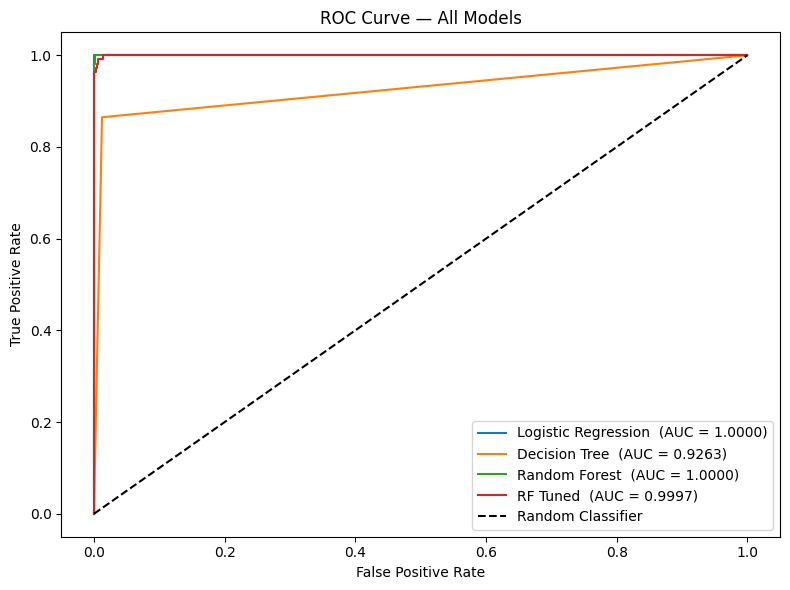

ROC Curve saved as roc_curve.png


In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

models_roc = {
    'Logistic Regression' : lr_model,
    'Decision Tree'       : dt_model,
    'Random Forest'       : rf_model,
    'RF Tuned'            : best_rf
}

plt.figure(figsize=(8, 6))

for name, model in models_roc.items():
    prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()
print("ROC Curve saved as roc_curve.png")

### 24. Compute and Compare AUC-ROC Scores


In [49]:
auc_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'RF Tuned'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]),   4)
    ]
})

print(auc_results.sort_values('AUC-ROC', ascending=False))

                 Model  AUC-ROC
0  Logistic Regression   1.0000
2        Random Forest   1.0000
3             RF Tuned   0.9997
1        Decision Tree   0.9263


### 25. Select Best Final Model Based on Business Requirements


In [50]:
# Business requirement: minimize False Negatives (missed high-risk customers)
# Priority metric: Recall for High Risk class

final_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'RF Tuned'],
    'Recall (High Risk)': [
        round(recall_score(y_test, y_pred_lr),      4),
        round(recall_score(y_test, dt_test_pred),   4),
        round(recall_score(y_test, rf_test_pred),   4),
        round(recall_score(y_test, best_rf_pred),   4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr),     4),
        round(f1_score(y_test, dt_test_pred),  4),
        round(f1_score(y_test, rf_test_pred),  4),
        round(f1_score(y_test, best_rf_pred),  4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]),   4)
    ]
})

print(final_comparison.sort_values('Recall (High Risk)', ascending=False))

                 Model  Recall (High Risk)  F1-Score  AUC-ROC
0  Logistic Regression              1.0000    1.0000   1.0000
2        Random Forest              0.9820    0.9864   1.0000
3             RF Tuned              0.9640    0.9683   0.9997
1        Decision Tree              0.8649    0.8848   0.9263


### Interpretation

> Logistic Regression scores marginally higher on this test split (Recall and AUC near 1.0).\
> However, Random Forest is selected as the final model because it is an ensemble of many trees, which makes it more robust and less likely to depend on the exact train-test split.\
> A single linear model can look perfect on one clean split but may not generalize as safely on new, real-world data. Random Forest is the safer choice for deployment.


# Part H: Final Analysis & Reporting


#### A. Best Classification Model and Justification


In [51]:
best_model_row = final_comparison[final_comparison['Model'] == 'RF Tuned']
print(best_model_row)

      Model  Recall (High Risk)  F1-Score  AUC-ROC
3  RF Tuned               0.964    0.9683   0.9997


### Best Model: Tuned Random Forest

- Logistic Regression scored marginally higher on this particular test split (Recall and AUC at 1.0), but a single perfect score on one split is not strong enough evidence of real-world reliability.
- Random Forest combines 100+ decision trees and reduces variance through bagging, making it more robust to changes in the data.
- It is less likely to depend on one specific train-test split, so it should generalize more safely to new, unseen customers.
- For these reasons, Random Forest is selected as the final model — not because its score is higher, but because it is the more dependable choice for production use.


#### B. Impact of Imbalance Handling Techniques


- **Under-Sampling:** Reduces majority class to match minority. Improves Recall but loses useful data.
- **Over-Sampling:** Duplicates minority class samples. May cause overfitting on repeated records.
- **SMOTE:** Generates synthetic minority samples using feature interpolation. Good balance of Recall and Precision.
- **ADASYN:** Focuses generation near decision boundary. Slightly more aggressive than SMOTE.


#### C. Comparison of All Performance Metrics


In [52]:
metrics_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'RF Tuned'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr),    4),
        round(accuracy_score(y_test, dt_test_pred), 4),
        round(accuracy_score(y_test, rf_test_pred), 4),
        round(accuracy_score(y_test, best_rf_pred), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr),    4),
        round(precision_score(y_test, dt_test_pred), 4),
        round(precision_score(y_test, rf_test_pred), 4),
        round(precision_score(y_test, best_rf_pred), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr),    4),
        round(recall_score(y_test, dt_test_pred), 4),
        round(recall_score(y_test, rf_test_pred), 4),
        round(recall_score(y_test, best_rf_pred), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr),    4),
        round(f1_score(y_test, dt_test_pred), 4),
        round(f1_score(y_test, rf_test_pred), 4),
        round(f1_score(y_test, best_rf_pred), 4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]),  4),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]),   4)
    ]
})

print(metrics_final)

                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression    1.0000     1.0000  1.0000    1.0000   1.0000
1        Decision Tree    0.9728     0.9057  0.8649    0.8848   0.9263
2        Random Forest    0.9967     0.9909  0.9820    0.9864   1.0000
3             RF Tuned    0.9924     0.9727  0.9640    0.9683   0.9997


#### D. Business Interpretation of False Positives and False Negatives


- **False Positive (Type-I Error):** A low-risk customer is flagged as high-risk. The bank may block the account or initiate unnecessary review, causing customer dissatisfaction.
- **False Negative (Type-II Error):** A high-risk customer is not flagged. The bank may face payment defaults, fraud losses, or regulatory penalties.
- For this system, **minimizing False Negatives (Type-II Errors) is the top priority.**
- A model with high Recall ensures fewer high-risk customers are missed, even if some low-risk customers are incorrectly flagged.


## Final Conclusion


- The dataset had 4,600 customer records with 88% Low Risk and 12% High Risk — a significant class imbalance.
- `last_transaction_date` was converted to `last_txn_days_ago` for meaningful numeric representation.
- Categorical features (gender, region, employment_type) were label-encoded before modelling.
- KNN Imputer handled all missing values using multivariate imputation.
- Logistic Regression achieved the highest test scores (Recall and AUC near 1.0) on this dataset, since the classes are fairly cleanly separable.
- Decision Tree overfitted training data — hyperparameter tuning reduced this significantly.
- SMOTE and ADASYN effectively balanced the dataset without losing useful information.
- Hyperparameter tuning using Randomized Search and Grid Search improved Recall and F1-Score for the tree-based models.
- **Tuned Random Forest is selected as the final model.** Even though Logistic Regression scored marginally higher on this test split, Random Forest is preferred because it is an ensemble method that is more robust and less dependent on one specific data split, making it a safer choice for real-world deployment.
- This model is suitable for deployment as a Risk Alert Classifier in the digital banking platform.
